# **Bioinformatics Project - Computational Drug Discovery [Part 4] Regression Models with Random Forest**


## **1. Import libraries**

In [20]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

## **2. Load the data set**

In [21]:
df = pd.read_csv('CORONA_bioactivity_data_3class_pIC50_pubchem_fp.csv')

### **3.1. Input features**

In [22]:
X = df.drop('pIC50', axis=1)
X

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
68,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
69,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
70,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


### **3.2. Output features**

In [23]:
Y = df.pIC50
Y

,pIC50
0,4.869666
1,4.882397
2,6.008774
3,6.022276
4,4.950782
...,...
67,4.950000
68,4.958607
69,5.000000
70,5.000000


### **3.3. Let's examine the data dimension**

In [24]:
X.shape

(72, 881)

In [25]:
Y.shape

(72,)

### **3.4. Remove low variance features**

In [26]:
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)

In [27]:
X.shape

(72, 163)

## **4. Data split (80/20 ratio)**

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [29]:
X_train.shape, Y_train.shape

((57, 163), (57,))

In [30]:
X_test.shape, Y_test.shape

((15, 163), (15,))

## **5. Building a Regression Model using Random Forest**

In [31]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, Y_train)
r2 = model.score(X_test, Y_test)
r2

0.7153686366923074

In [32]:
Y_pred = model.predict(X_test)

## **6. Scatter Plot of Experimental vs Predicted pIC50 Values**

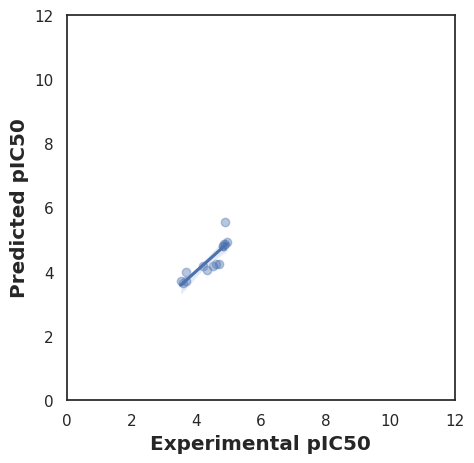

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True)
sns.set_style("white")

ax = sns.regplot(x=Y_test, y=Y_pred, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.figure.set_size_inches(5, 5)
plt.show()